## Milestone 4 — Incident Type Analysis
 The goal of this milestone is to perform a detailed analysis of disaster incident types and integrate insights from previous milestones (temporal and geographical analysis) into a coherent final narrative.

 1. Dataset Preparation

In [3]:
###################################################### STEP - 1 #########################################################

import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\tanus\Desktop\Tanu\US Disaster Visualization\data\processed\usnd_cleaned.csv")

# Preview
df.head()

# Changing column names
print(df.info())
df = df.rename(columns={
    'State': 'state',
    'Disaster Type': 'incidentType',
    'Declaration Date': 'declarationDate',
    'Individual Assistance Program': 'ihProgramDeclared',
    'Public Assistance Program': 'paProgramDeclared'
})
# Convert Date column
df['declarationDate'] = pd.to_datetime(
    df['declarationDate'],
    errors='coerce'
)

# Create Year & Time feature
df['year'] = df['declarationDate'].dt.year
df['month'] = df['declarationDate'].dt.month

# Convert assistance program to boolean
df['ihProgramDeclared'] = df['ihProgramDeclared'].map({
    'Yes': 1,
    'No': 0
})

df['paProgramDeclared'] = df['paProgramDeclared'].map({
    'Yes': 1,
    'No': 0
})

print(df.columns)

# Validate required columns
required_columns = [
    'incidentType',
    'state',
    'year',
    'month',
    'ihProgramDeclared',
    'paProgramDeclared'
]

for col in required_columns:
    if col in df.columns:
        print(f"{col} ✔ Present")
    else:
        print(f"{col} ❌ Missing")

# Saving final clean dataset
df.to_csv(r"C:\Users\tanus\Desktop\Tanu\US Disaster Visualization\data\processed\usnd_cleaned.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Declaration Number                46185 non-null  str    
 1   Declaration Type                  46185 non-null  str    
 2   declarationDate                   18639 non-null  str    
 3   state                             46185 non-null  str    
 4   County                            45988 non-null  str    
 5   incidentType                      46185 non-null  str    
 6   Disaster Title                    46185 non-null  str    
 7   Start Date                        46185 non-null  str    
 8   End Date                          45843 non-null  str    
 9   Close Date                        35210 non-null  str    
 10  ihProgramDeclared                 46185 non-null  int64  
 11  Individuals & Households Program  46185 non-null  str    
 12  paProgramDeclar

2. Incident Type Distribution Analysis : Understand the overall distribution of disaster types.

incidentType
Storm              16250
Flood               9317
Hurricane           8764
Snow                3565
Fire                2647
Ice                 1970
Tornado             1412
Drought             1292
Winter               301
Other                297
Typhoon              119
Earthquake           105
Volcano               50
Water                 42
Chemical              18
Mud/Landslide         10
Tsunami                9
Dam/Levee Break        6
Human Cause            6
Terrorism              5
dtype: int64


C:\Users\tanus\AppData\Local\Temp\ipykernel_24612\2487438190.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


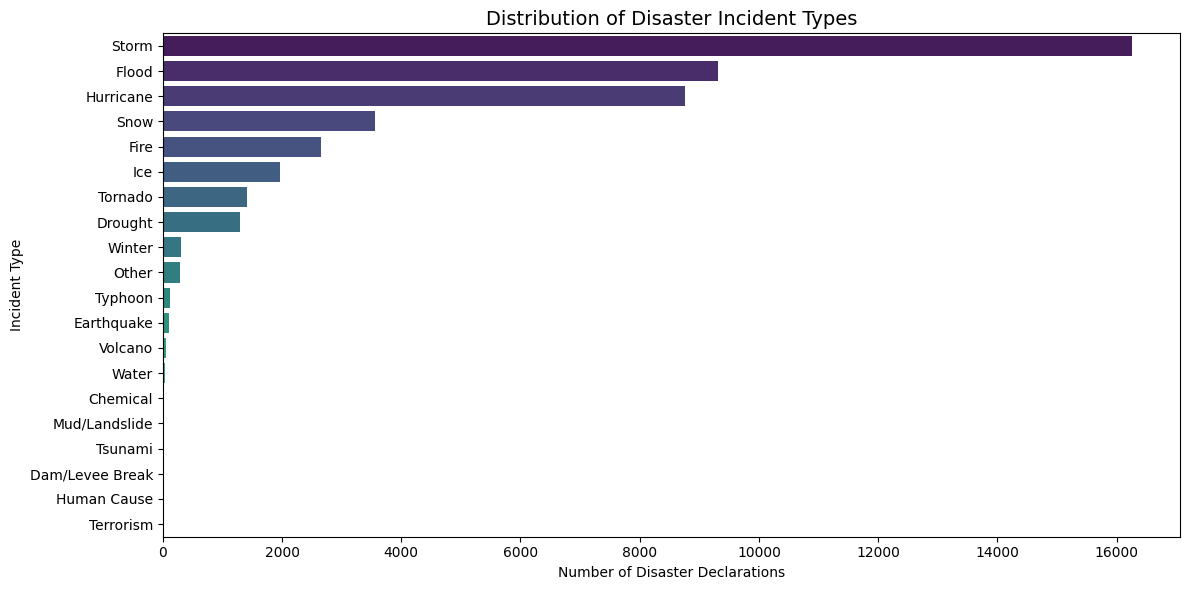

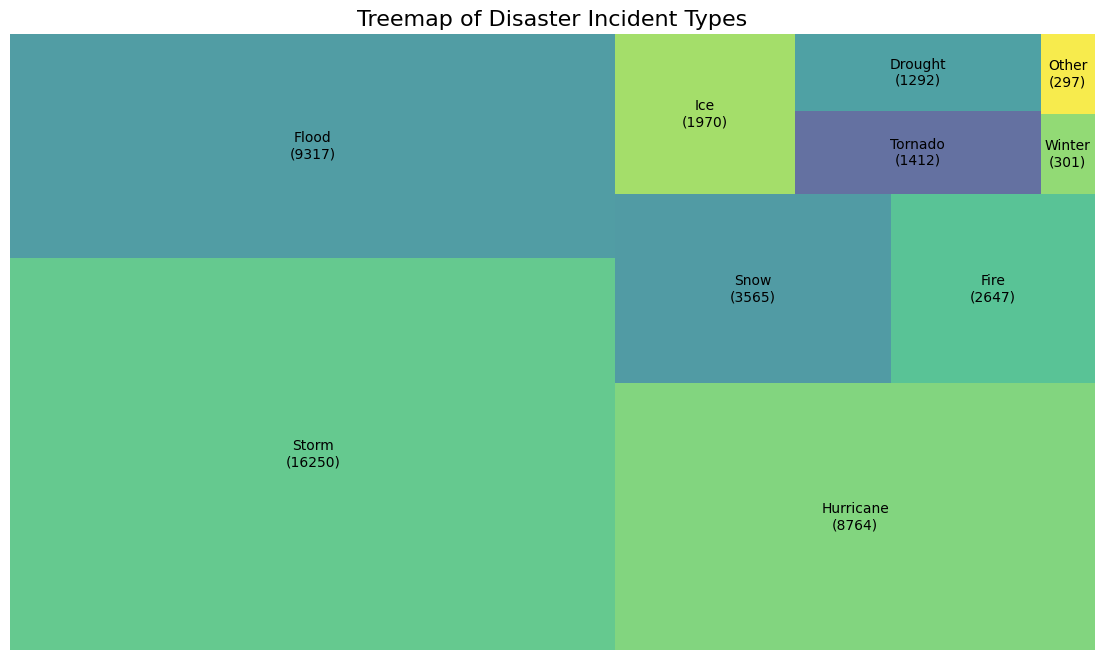

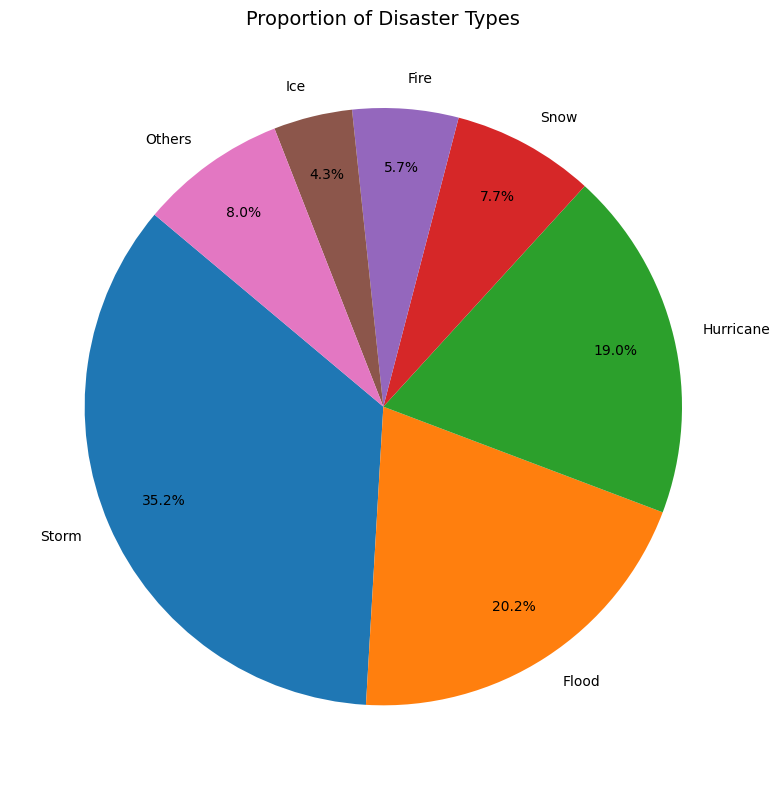

In [12]:
import seaborn as sns

# Count disaster declarations per incident type
incident_counts = (
    df.groupby('incidentType')
      .size()
      .sort_values(ascending=False)
)

print(incident_counts)

# Visualization 1- Bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=incident_counts.values,
    y=incident_counts.index,
    palette="viridis"
)

plt.title("Distribution of Disaster Incident Types", fontsize=14)
plt.xlabel("Number of Disaster Declarations")
plt.ylabel("Incident Type")

plt.tight_layout()
plt.show()

# Visualization 2 - Treemap
import squarify

top_incidents = incident_counts.head(10)

plt.figure(figsize=(14,8))

squarify.plot(
    sizes=top_incidents.values,
    label=[f"{i}\n({v})" for i, v in zip(top_incidents.index, top_incidents.values)],
    alpha=0.8
)

plt.title("Treemap of Disaster Incident Types", fontsize=16)
plt.axis('off')

plt.show()

# Visualization 3 - Piechart 
top6 = incident_counts.head(6)
others = incident_counts.iloc[6:].sum()

pie_data = top6.copy()
pie_data["Others"] = others

plt.figure(figsize=(8,8))

plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

plt.title("Proportion of Disaster Types", fontsize=14)

plt.tight_layout()
plt.show()

3. State vs Incident Type Analysis : Analyze how disaster types are distributed across different states.

  state incidentType  DisasterCount
0    AK   Earthquake              7
1    AK         Fire             16
2    AK        Flood             46
3    AK        Other              4
4    AK         Snow              4
incidentType  Chemical  Dam/Levee Break  Drought  Earthquake  Fire  Flood  \
state                                                                       
AK                 0.0              0.0      0.0         7.0  16.0   46.0   
AL                 0.0              0.0     67.0         0.0  11.0  104.0   
AR                 0.0              0.0     32.0         0.0   0.0  235.0   
AS                 0.0              0.0      5.0         5.0   0.0    5.0   
AZ                 0.0              0.0      8.0         0.0  44.0   77.0   

incidentType  Human Cause  Hurricane    Ice  Mud/Landslide  Other  Snow  \
state                                                                     
AK                    0.0        0.0    0.0            0.0    4.0   4.0   
AL                 

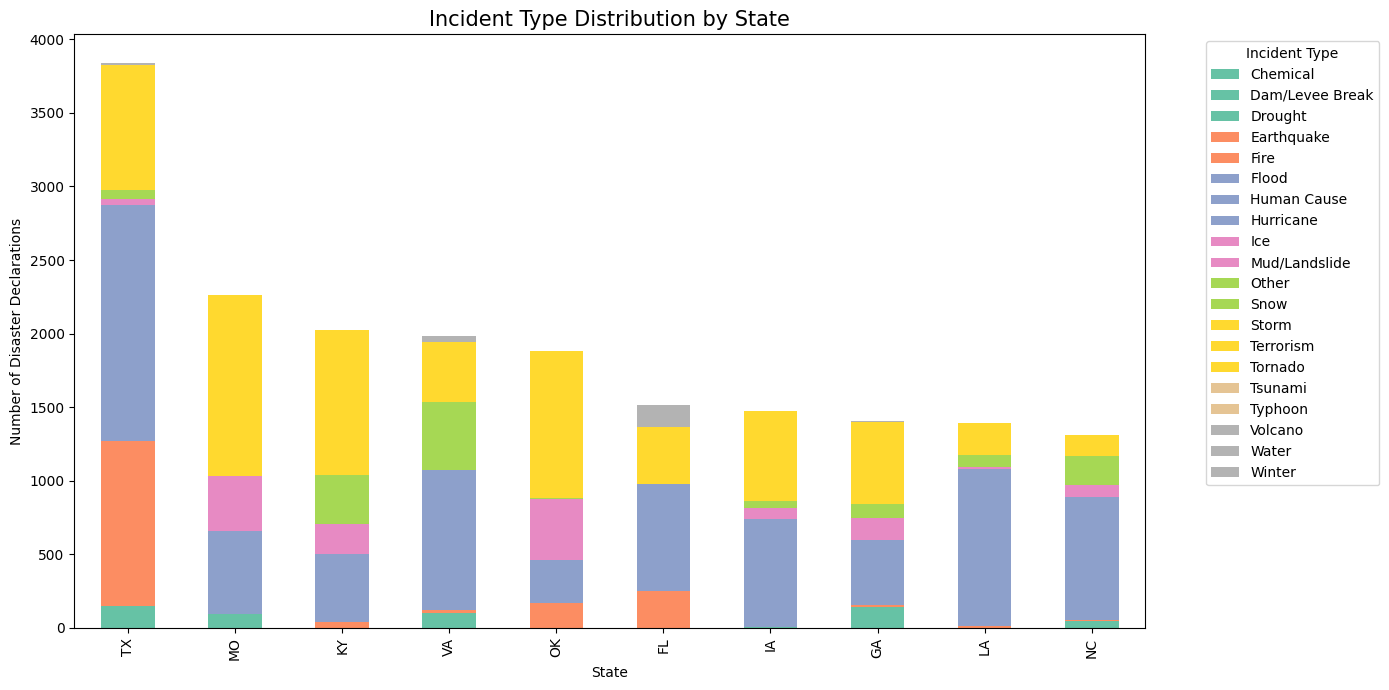

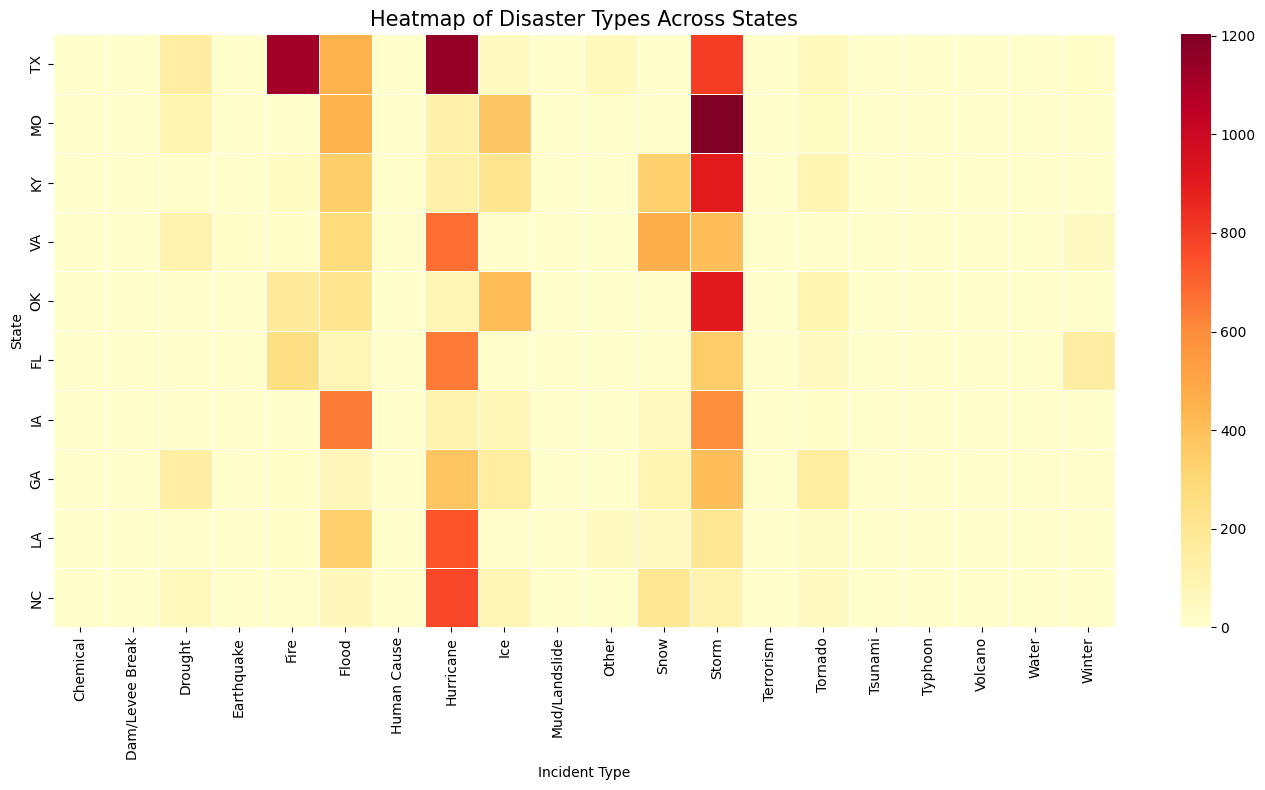

In [16]:
# Group by State and Incident Type
state_incident = (
    df.groupby(['state', 'incidentType'])
      .size()
      .reset_index(name='DisasterCount')
)

print(state_incident.head())

# Pivot table -- For data Visulization
pivot_table = state_incident.pivot(
    index='state',
    columns='incidentType',
    values='DisasterCount'
).fillna(0)

print(pivot_table.head())

# Select Top 10 disaster-prone states
top_states = pivot_table.sum(axis=1).sort_values(ascending=False).head(10)

top_pivot = pivot_table.loc[top_states.index]

# Plot
top_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7),
    colormap=sns.color_palette("Set2", as_cmap=True)
)

plt.title("Incident Type Distribution by State", fontsize=15)
plt.xlabel("State")
plt.ylabel("Number of Disaster Declarations")
plt.legend(title="Incident Type", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

# Heatmap Visualization
plt.figure(figsize=(14,8))

sns.heatmap(
    top_pivot,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Heatmap of Disaster Types Across States", fontsize=15)
plt.xlabel("Incident Type")
plt.ylabel("State")

plt.tight_layout()
plt.show()


4. Disaster Assistance Program Analysis


[0]
[0]
                 ihProgramDeclared  paProgramDeclared
incidentType                                         
Chemical                         0                  0
Dam/Levee Break                  0                  0
Drought                          0                  0
Earthquake                       0                  0
Fire                             0                  0


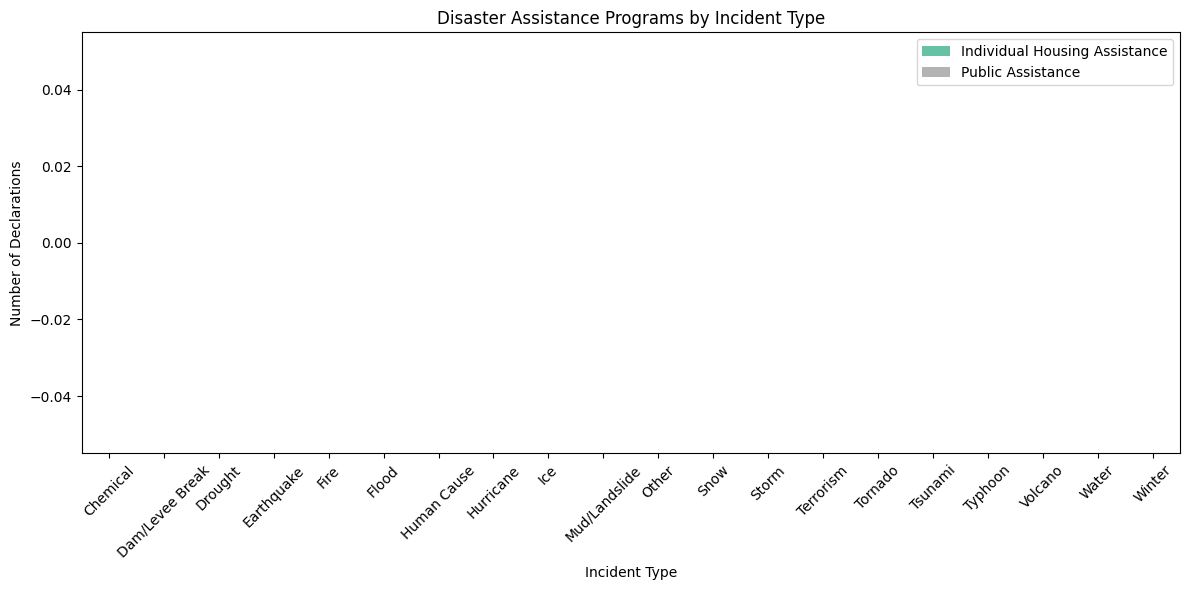

In [32]:
# Check origional values in assistance columns
print(df['ihProgramDeclared'].unique())
print(df['paProgramDeclared'].unique())

# Convert assistance columns to numeric
# Convert to binary (1 = Declared, 0 = Not Declared)
df['ihProgramDeclared'] = df['ihProgramDeclared'].apply(
    lambda x: 1 if str(x).strip().lower() in ['yes','y','true','1','declared'] else 0
)

df['paProgramDeclared'] = df['paProgramDeclared'].apply(
    lambda x: 1 if str(x).strip().lower() in ['yes','y','true','1','declared'] else 0
)

# Aggregate assistance by incident type
assistance_analysis = (
    df.groupby('incidentType')[['ihProgramDeclared','paProgramDeclared']]
      .sum()
      .sort_values(by='ihProgramDeclared', ascending=False)
)

print(assistance_analysis.head())


# Visualization 1 - Bar chart
assistance_analysis.plot(
    kind='bar',
    figsize=(12,6),
    colormap='Set2'
)

plt.title("Disaster Assistance Programs by Incident Type")
plt.xlabel("Incident Type")
plt.ylabel("Number of Declarations")
plt.xticks(rotation=45)
plt.legend(["Individual Housing Assistance","Public Assistance"])
plt.tight_layout()
plt.show()

